# **Homework 2**

*Artificial Intelligence II - Fall Semester 2021*

*Deep Learning for Natural Language Processing*


---



Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Imports**

Import needed libraries and download packages "punkt" and "popular"

In [2]:
import pandas as pd
import scipy
from string import digits
import re

import matplotlib.pyplot as plt

import numpy as np
import nltk

nltk.download('punkt')
nltk.download('popular')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from scipy import interp
from sklearn.metrics import roc_auc_score

# from functools import reduce
# import operator
from itertools import cycle

import torch

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    | 

Read train data from csv file.

In [3]:
df_train = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_train.csv", index_col=[0])
df_train.head()

,tweet,label
0,Sip N Shop Come thru right now #Marjais #Popul...,0
1,I don't know about you but My family and I wil...,1
2,@MSignorile Immunizations should be mandatory....,2
3,President Obama spoke in favor of vaccination ...,0
4,"""@myfoxla: Arizona monitoring hundreds for mea...",0


Read test data from csv file.

In [4]:
df_test = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_dev.csv", index_col=[0])
df_test.head()

,tweet,label
0,@user They had a massive surge in with covid d...,1
1,Required vaccines for school: Parents and guar...,0
2,“@KCStar: Two more Johnson County children hav...,0
3,NV can do better. Which states are the best (a...,2
4,Nothing like killing ourselves w/ our own fear...,2


## **Data Preprocess**



---

###Text Data Cleaning

>For the data cleaning process, the following were included: 
* Remove all whitespaces and newlines 
* Remove all special characters and punctuation
* Replace contractions with full words (despite that they might be removed   later from the stopwords)
* Splitted attached words e.g.  “ForTheWin” =>  “For The Win”
* Lowered all capital letters  
* Removed Numbers from text corpus
* Standarizing sentences

>Both train and test data are preprocessed in the same exact way.

>(reference link: [python-efficient-text-data-cleaning](https://www.geeksforgeeks.org/python-efficient-text-data-cleaning/)

In [5]:
def numbers(x):
  return re.sub(r'[0-9]+', '', x)

def blank_space(x):
  return re.sub('[^A-Za-z0-9]+', ' ', x)

def standarize_sentence(x):
  return ''.join(''.join(word)[:2] for word in x) 

def apostrophe_words(x):
  Apos_dict={"'s":" is","'t":" not","'m":" am","'ll":" will", "'d":" would","'ve":" have","'re":" are", 
             "’s":" is","’t":" not","’m":" am", "’d":" would","’ve":" have","’re":" are", "’ll": "will"} 
  for key,value in Apos_dict.items(): 
    if key in x:
      x =  x.replace(key,value)
      return x
  return x

def split_words(x):
  return " ".join([word for word in re.split("([A-Z][a-z]+[^A-Z]*)",x) if word])

def shallow_cleaning(df):
  remove_digits = str.maketrans('', '', digits)
  df['tweet'] = df['tweet'].apply(lambda x: blank_space(x))
  df['tweet'] = df['tweet'].apply(lambda x: apostrophe_words(x))
  df['tweet'] = df['tweet'].str.strip()
  df['tweet'] = df['tweet'].str.lower()
  df['tweet'] = df['tweet'].apply(lambda x: numbers(x))
  df['tweet'] = df['tweet'].apply(lambda x: split_words(x))
  df['tweet'] = df['tweet'].apply(lambda x: standarize_sentence(x))
  return df

df_train = shallow_cleaning(df_train)
display(df_train)

,tweet,label
0,sip n shop come thru right now marjais popular...,0
1,i don t know about you but my family and i wil...,1
2,msignorile immunizations should be mandatory p...,2
3,president obama spoke in favor of vaccination ...,0
4,myfoxla arizona monitoring hundreds for measle...,0
...,...,...
15971,salon if u believe the anti vax nutcases cause...,1
15972,how do you feel about parents who don t vaccin...,0
15973,preschoolers tested for measles in simi valle...,0
15974,finance minister budget offers room to procure...,0


In [6]:
df_test = shallow_cleaning(df_test)
display(df_test)

,tweet,label
0,user they had a massive surge in with covid de...,1
1,required vaccines for school parents and guard...,0
2,kcstar two more johnson county children have m...,0
3,nv can do better which states are the best and...,2
4,nothing like killing ourselves w our own fear ...,2
...,...,...
2277,rt abc number of measles cases reported in cal...,0
2278,evidence points to the idea that measles affec...,0
2279,where s savedyouaclick voxdotcom why you shoul...,2
2280,some of my favorite people have autism if that...,2


## Stemming

To enhance the classification performance we proceeded to stem the data of *Title Content* column. 

Stemming is a Text Normalization (or sometimes called Word Normalization) techniques in the field of Natural Language Processing that are used to prepare text, words, and documents for further processing. Stemming helps us to achieve the root forms (sometimes called synonyms in search context) of inflected (derived) words. Thus, we define as Stem (root) the part of the word to which we add inflectional (changing/deriving) affixes such as (-ed,-ize, -s,-de,mis). So stemming a word or sentence may result in words that are not actual words. Stems are created by removing the suffixes or prefixes used with a word.

For this process we used PorterStemmer for the English language. 

Stemming is applied both on the train and test dataset.

In [7]:
porter = PorterStemmer()

def stemming(df):
  df = df.apply(lambda x: word_tokenize(x))
  df = df.apply(lambda x: [porter.stem(word) for word in x])
  df = df.apply(lambda x: ' '.join(str(word) for word in x))
  return df

df_train['stemmed'] = stemming(df_train['tweet'])

df_train.head()

,tweet,label,stemmed
0,sip n shop come thru right now marjais popular...,0,sip n shop come thru right now marjai popularn...
1,i don t know about you but my family and i wil...,1,i don t know about you but my famili and i wil...
2,msignorile immunizations should be mandatory p...,2,msignoril immun should be mandatori period in ...
3,president obama spoke in favor of vaccination ...,0,presid obama spoke in favor of vaccin for chil...
4,myfoxla arizona monitoring hundreds for measle...,0,myfoxla arizona monitor hundr for measl link t...


In [8]:
df_test['stemmed'] = stemming(df_test['tweet'])

df_test.head()

,tweet,label,stemmed
0,user they had a massive surge in with covid de...,1,user they had a massiv surg in with covid deat...
1,required vaccines for school parents and guard...,0,requir vaccin for school parent and guardian o...
2,kcstar two more johnson county children have m...,0,kcstar two more johnson counti children have m...
3,nv can do better which states are the best and...,2,nv can do better which state are the best and ...
4,nothing like killing ourselves w our own fear ...,2,noth like kill ourselv w our own fear mt alyss...


## **Vectorizers**


---


### TF-IDF

We use the tfidf vectorizer to create the bag of words. TF-IDF stands for Term Frequency-Inverse Document Frequency. The Bag of Words (BoW) model is the simplest form of text representation in numbers. Like the term itself, we can represent a sentence as a bag of words vector (a string of numbers). A simple Bag of Words (like one created with the use of CountVectorizer class), just creates a set of vectors containing the count of word occurrences in the corpus given. On the other hand, the TF-IDF model contains information on the more important words and the less important ones as well. In this case we create a BoW with the default number of  features. 

In [9]:
stop_words = nltk.corpus.stopwords.words('english')

def getBOWTfidf(df, min_df = 0, max_df = 1, ngrams = 1,analyzer = 'word', max_features=10000):
  BOW = TfidfVectorizer(min_df=min_df, max_df=max_df, lowercase=True, stop_words=stopwords.words('english'), max_features=10000)
  BOW.fit(df.values.astype('U'))
  print('Tf-idf Vocabulary size is {}'.format(len(BOW.vocabulary_)))
  return BOW

BOW = getBOWTfidf(df_train['stemmed'], max_df=0.99, ngrams = 1)

x_train = BOW.transform(df_train['stemmed'].values.astype('U')) 
x_test = BOW.transform(df_test['stemmed'].values.astype('U'))

Tf-idf Vocabulary size is 10000


Mount available CUDA device


In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [11]:
!nvidia-smi -q


==============NVSMI LOG==============

Timestamp                                 : Thu Dec 23 15:06:54 2021
Driver Version                            : 460.32.03
CUDA Version                              : 11.2

Attached GPUs                             : 1
GPU 00000000:00:04.0
    Product Name                          : Tesla K80
    Product Brand                         : Tesla
    Product Architecture                  : Kepler
    Display Mode                          : Disabled
    Display Active                        : Disabled
    Persistence Mode                      : Disabled
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : N/A
        Pending                           : N/A
    Serial Number                         : 0320415051158
    GPU UUID            

### Tensor Creation

In [12]:
y_df = pd.DataFrame(df_train, columns=[df_train.columns[-2]])
y_df_val = pd.DataFrame(df_test, columns=[df_train.columns[-2]])

#if we run on cuda device
if device == 'cuda':
  x = torch.tensor(x_train.todense(), dtype=torch.float, requires_grad=True).to('cuda')
  y = torch.tensor(y_df.values, dtype=torch.long).to('cuda')

  x_val = torch.tensor(x_test.todense(), dtype=torch.float, requires_grad=True).to('cuda')
  y_val = torch.tensor(y_df_val.values, dtype=torch.long).to('cuda')
else: 
  x = torch.tensor(x_train.todense(), dtype=torch.float, requires_grad=True)
  y = torch.tensor(y_df.values, dtype=torch.long)

  x_val = torch.tensor(x_test.todense(), dtype=torch.float, requires_grad=True)
  y_val = torch.tensor(y_df_val.values, dtype=torch.long)

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")

x shape: torch.Size([15976, 10000])
y shape: torch.Size([15976, 1])
x_val shape: torch.Size([2282, 10000])
y_val shape: torch.Size([2282, 1])


*   ***getMax(array, size):*** returns the position of the max element in a dataframe row
*   ***getPrediction(y_pred, out_dim=1):*** returns the prediction with the labels

In [13]:
def getMax(array, size):
  max = -1
  counter = 0
  for element in array:
    if max < element:
      max = element
      label = counter
    counter+=1
  return label

def getPrediction(y_pred, out_dim=1):
  res_list = []
  for line in y_pred:
    res_list.append(getMax(line, 3))
  res_df = pd.DataFrame(data=res_list, columns=['Predicted Labels'])
  if device == 'cuda':
    return torch.tensor(res_df.values, dtype=torch.long).to('cuda')
  else:
    return torch.tensor(res_df.values, dtype=torch.long)

### Define Neural Network

**Architecture:**
*   Linear layer with input input_size -  the size of the dataset and output_size the size of the hidden layer
*   ReLu activation function
*   Linear layer with input_size the size of the previous hidden layer and output_size the number of the classes of the problem (in our case that will be 3)



In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FeedForward(nn.Module):
  def __init__(self, input_size, H1, output_size):
      super(FeedForward, self).__init__()

      self.input_size = input_size
      self.H1  = H1
      self.output_size = output_size

      self.fc1 = nn.Linear(self.input_size, self.H1)
      self.relu = nn.ReLU()
      self.fc2 = nn.Linear(self.H1, self.output_size)
  
  def forward(self, x):
      hidden1 = self.fc1(x)
      relu1 = self.relu(hidden1)
      output = self.fc2(relu1)
      return output



### Model Initialization



*   input_size: the size of the input dataset
*   H1: hidden layer size
*   output_size: the number of classes of the problem (in our case 3)
*   Learning rate: after multiple experiments 0.005 is thought to be the best choice
*   Loss function: CrossEntropyLoss is used. It is considered the best choice for multiclass classiication problems.
*   Optimizer: Adam - has good performance overall. I did also try SGD but it had dissaponting results


In [15]:
#Define layer sizes
input_size = x.shape[1]
H1 = 32
output_size = 3

#Define Hyperparameters
learning_rate = 1e-4

#Initialize model, loss, optimizer
modelFF = FeedForward(input_size, H1, output_size)
loss_func = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(modelFF.parameters(), lr = 0.005)

if device == 'cuda':
  modelFF.to('cuda')
  loss_func.to('cuda')

#Initialize dataloader
dataset = torch.utils.data.TensorDataset(x, y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

In [16]:
modelFF

FeedForward(
  (fc1): Linear(in_features=10000, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)

### Train Network

Epochs: 5 (after the conduction of multiple experiments)

The model is trained with the entire train dataset and then tested (as a mockup) with the same dataset.

In [17]:
train_loss = []
val_loss = []

train_stats = {'train_loss': [], 'val_loss': []}

for epoch in range(5):
  batch_losses = []
  running_loss = 0.0
  
  modelFF.train()
  for x_batch, y_batch in dataloader:
    y_pred = modelFF(x_batch)

    loss = loss_func(y_pred, y_batch.flatten())
    batch_losses.append(loss.item())
    
    # Delete previously stored gradients
    optimizer.zero_grad()
    # Perform backpropagation starting from the loss calculated in this epoch
    loss.backward()
    # Update model's weights based on the gradients calculated during backprop
    optimizer.step()
    # print(f"Batch loss = {loss.item()}")
    
  print(f"Epoch {epoch:3}: Loss = {float(sum(batch_losses))/len(dataloader)}")

  train_stats['train_loss'].append(float(sum(batch_losses))/len(dataloader))
  
  # Compute the validation score
  modelFF.eval()
  running_loss_val = 0.0

  for x_batch, y_batch in dataloader:
    y_pred = modelFF(x_batch)
    
    loss = loss_func(y_pred, y_batch.flatten())
    
    running_loss += float(sum(batch_losses))/len(dataloader)

  train_stats['val_loss'].append(running_loss)


Epoch   0: Loss = 49.1734423828125
Epoch   1: Loss = 32.31916429901123
Epoch   2: Loss = 23.67152813720703
Epoch   3: Loss = 17.536940464019775
Epoch   4: Loss = 13.002559803009033


Train Statistics Report


*   Train Loss: Model loss monitored during training phase
*   Val_Loss: Model loss monitored during evaluation phase



In [18]:
train_stats_df = pd.DataFrame(train_stats)
display(train_stats_df)

,train_loss,val_loss
0,49.173442,12293.360596
1,32.319164,8079.791075
2,23.671528,5917.882034
3,17.536940,4384.235116
4,13.002560,3250.639951


Graphic represantation of train and evaluation loss for train dataset

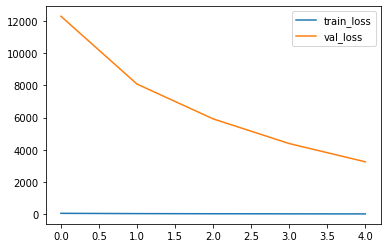

In [19]:
train_stats_df.plot()

Batch Losses

In [20]:
batch_losses_df = pd.DataFrame(batch_losses, columns=['Batch Loss'])
display(pd.DataFrame(batch_losses_df))

,Batch Loss
0,8.157417
1,9.850411
2,8.773458
3,6.135525
4,12.037906
...,...
245,13.399169
246,17.885550
247,16.068027
248,21.603514


Graphic representation of batch losses

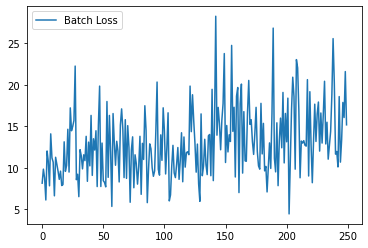

In [21]:
batch_losses_df.plot()

Save model

In [22]:
PATH = '/content/drive/MyDrive/University/Vaccine Sentiment Dataset/model'
torch.save({
            'epoch': 4,
            'model_state_dict': modelFF.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': float(sum(batch_losses_df['Batch Loss'].tail(1)))/len(dataloader),
            }, PATH)

### Prediction

Model prediction for the test data.

In [23]:
#Initialize dataloader for test dataset
val_dataset = torch.utils.data.TensorDataset(x_val, y_val)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=True)

prediction = []
y_actual = []
y_test = []
batch_num = 0.0

modelFF.eval()
accuracy = 0.0
f1 = 0.0
recall = 0.0
precision = 0.0
metrics = {'accuracy':0.0,
           'f1':0.0,
           'recall':0.0,
           'precision':0.0}

for i_batch, batch in val_dataloader:
  
  batch_num += 1
  batch_prediction = []
  y_batch = []

  test_pred = modelFF(i_batch)
  test_label_pred = getPrediction(test_pred, 3)

  test_pred = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_actual = np.array(batch.cpu().flatten().detach().tolist())

  batch_prediction = np.array(test_label_pred.cpu().flatten().detach().tolist())
  y_batch = np.array(batch.cpu().flatten().detach().tolist())

  prediction.append(test_label_pred.cpu().data.flatten().tolist())
  y_test.append(batch.cpu().flatten().detach().tolist())

  #Compute the scores.
  accuracy += accuracy_score(y_batch, batch_prediction)
  f1 += f1_score(y_batch, batch_prediction, average='micro')
  recall += recall_score(y_batch, batch_prediction, average='micro')
  precision += precision_score(y_batch, batch_prediction, average='micro')

prediction = sum(prediction, [])
y_test = sum(y_test, [])

metrics['accuracy'] = accuracy/batch_num
metrics['f1'] = f1/batch_num
metrics['recall'] = recall/batch_num
metrics['precision'] = precision/batch_num

In [24]:
display(pd.DataFrame(pd.Series(metrics)).T)

,accuracy,f1,recall,precision
0,0.669354,0.669354,0.669354,0.669354


Classification report for the prediction made with the test data. (Model is previously trained with the vocabulary provided by the train data)

It is obvious that the prediction does not fair well (better though than the experiments with the GloVe embedding)...
However this outcome is somewhat expected since the train dataset is considered small to train a model of this kind and be satisfied with the prediction results.

In [25]:
model_report = classification_report(y_test,prediction)
print(model_report)

              precision    recall  f1-score   support

           0       0.76      0.69      0.72      1065
           1       0.47      0.47      0.47       296
           2       0.64      0.70      0.67       921

    accuracy                           0.67      2282
   macro avg       0.62      0.62      0.62      2282
weighted avg       0.67      0.67      0.67      2282



### ROC-Curve

([Receiver operating characteristic](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html))

From the curve it is obvious that the False positive rate in classe 0(neutral) is quite high.

On the other hand, the model makes good enough (can always get better), predictions for classes 1 & 2 (anti-vax & pro-vax), with tha false positive rate being low.

All things considered, model tuning cannot always save the day. From a point after, especially in the case of neural networks, it is important to "feed" our network with a lots of data so that it can enhance its learning. Of course that does not enclose the cases where the model overfits.

In [26]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

y = label_binarize(y_actual, classes=[0, 1, 2])
n_classes = y.shape[1]

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_actual, test_pred, pos_label=i)
  roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_actual.ravel(), test_pred.ravel(), pos_label=2)
roc_auc_micro = auc(fpr["micro"], tpr["micro"])

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:8: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  


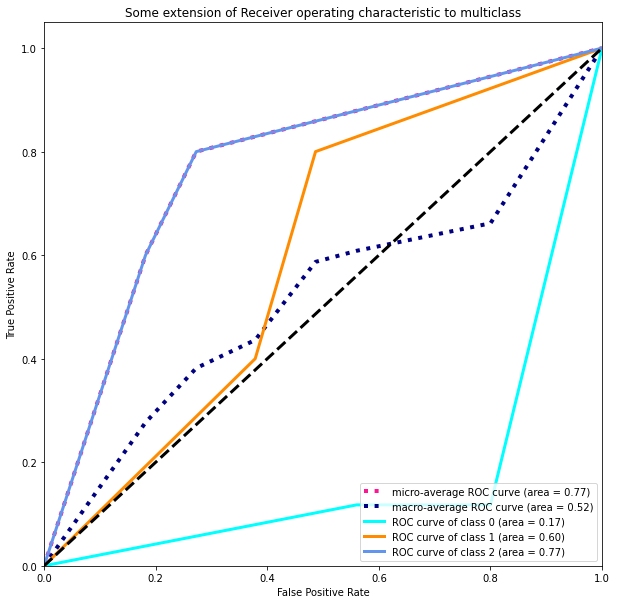

In [27]:
# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
lw = 3

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc_macro = auc(fpr["macro"], tpr["macro"])

data={"macro":roc_auc_macro, "micro":roc_auc_micro}
roc_auc_t = pd.Series(data=data, index=["macro", "micro"])

# Plot all ROC curves
plt.figure(figsize=(10,10))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="macro-average ROC curve (area = {0:0.2f})".format(roc_auc_t["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)


colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(n_classes), colors):
  plt.plot(
      fpr[i],
      tpr[i],
      color=color,
      lw=lw,
      label="ROC curve of class {0} (area = {1:0.2f})".format(i, roc_auc[(i)]),
  )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Some extension of Receiver operating characteristic to multiclass")
plt.legend(loc="lower right")
plt.show()